# 1. Example figure of I-V figures of 4 types of LEDs and the resistor
The averaged approach were conducted subsequently.

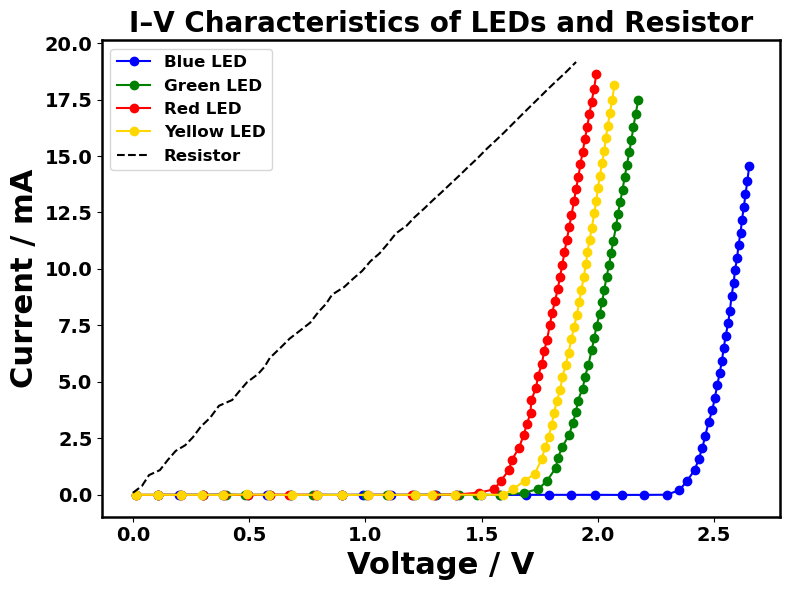

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    V = data[:, 0]
    I = data[:, 1]
    return V, I

# Load data
V_blue, I_blue = load_iv('/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/blue/blue_IV.csv')
V_green, I_green = load_iv('/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/green/green_IV.csv')
V_red, I_red = load_iv('/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/red/red_IV.csv')
V_yellow, I_yellow = load_iv('/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/yellow/yellow_IV.csv')
V_res, I_res = load_iv('/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/resistor/resistor_IV.csv')

# Plot
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)
plt.plot(V_blue, I_blue, 'o-', label='Blue LED', color='blue')
plt.plot(V_green, I_green, 'o-', label='Green LED', color='green')
plt.plot(V_red, I_red, 'o-', label='Red LED', color='red')
plt.plot(V_yellow, I_yellow, 'o-', label='Yellow LED', color='gold')
plt.plot(V_res, I_res, 'k--', label='Resistor')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('I–V Characteristics of LEDs and Resistor', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left')
#plt.grid(True)
plt.tight_layout()
plt.savefig("I–V Characteristics of LEDs and Resistor.png", dpi=600)
plt.show()

# 2. Average Performance of I-V figures of 4 types of LEDs and the resistor
Error bar anaylysis is also included

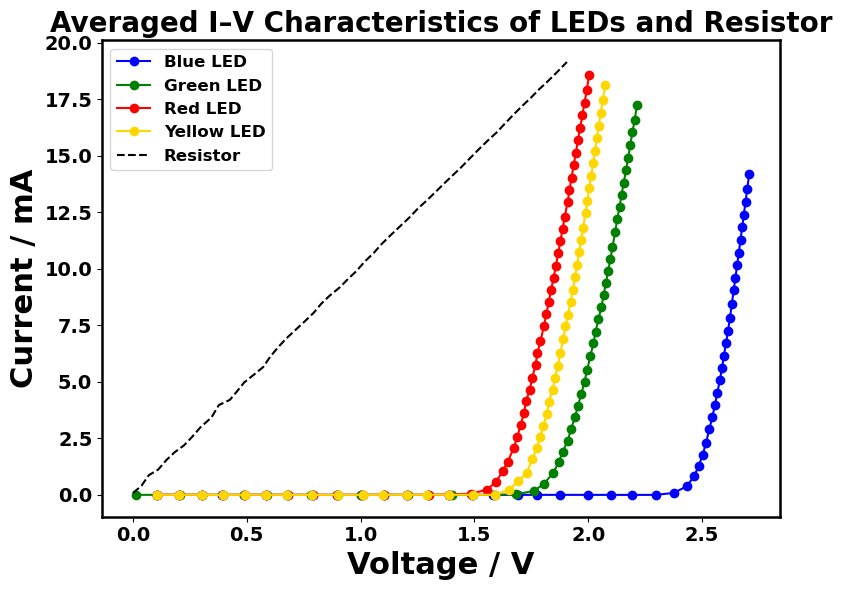

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs = []
    Is = []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V)
        Is.append(I)

    # target length = shortest run (e.g. 50)
    n = min(len(v) for v in Vs)

    Vs_trim = []
    Is_trim = []
    for V, I in zip(Vs, Is):
        # If longer (e.g. 51), discard the FIRST point(s)
        if len(V) > n:
            drop = len(V) - n
            V = V[drop:]
            I = I[drop:]
        else:
            V = V[:n]
            I = I[:n]
        Vs_trim.append(V)
        Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

base = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data'

V_blue_avg, I_blue_avg = average_iv([
    f'{base}/blue/blue_IV.csv',
    f'{base}/blue/blue_IV_2.csv',
    f'{base}/blue/blue_IV_3.csv',
    f'{base}/blue/blue_IV_4.csv',
    f'{base}/blue/blue_IV_5.csv',
])

V_green_avg, I_green_avg = average_iv([
    f'{base}/green/green_IV.csv',
    f'{base}/green/green_IV_2.csv',
    f'{base}/green/green_IV_3.csv',
    f'{base}/green/green_IV_4.csv',
    f'{base}/green/green_IV_5.csv',
])

V_red_avg, I_red_avg = average_iv([
    f'{base}/red/red_IV.csv',
    f'{base}/red/red_IV_2.csv',
    f'{base}/red/red_IV_3.csv',
    f'{base}/red/red_IV_4.csv',
    f'{base}/red/red_IV_5.csv',
])

V_yellow_avg, I_yellow_avg = average_iv([
    f'{base}/yellow/yellow_IV.csv',
    f'{base}/yellow/yellow_IV_2.csv',
    f'{base}/yellow/yellow_IV_3.csv',
    f'{base}/yellow/yellow_IV_4.csv',
    f'{base}/yellow/yellow_IV_5.csv',
])

V_res_avg, I_res_avg = average_iv([
    f'{base}/resistor/resistor_IV.csv',
    f'{base}/resistor/resistor_IV_2.csv',
    f'{base}/resistor/resistor_IV_3.csv',
    f'{base}/resistor/resistor_IV_4.csv',
    f'{base}/resistor/resistor_IV_5.csv',
])

plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_avg, I_blue_avg, 'o-', label='Blue LED', color='blue')
plt.plot(V_green_avg, I_green_avg, 'o-', label='Green LED', color='green')
plt.plot(V_red_avg, I_red_avg, 'o-', label='Red LED', color='red')
plt.plot(V_yellow_avg, I_yellow_avg, 'o-', label='Yellow LED', color='gold')
plt.plot(V_res_avg, I_res_avg, 'k--', label='Resistor')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Averaged I–V Characteristics of LEDs and Resistor', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left')
plt.tight_layout()
plt.savefig("Averaged I–V Characteristics of LEDs and Resistor.png", dpi=600)
plt.show()

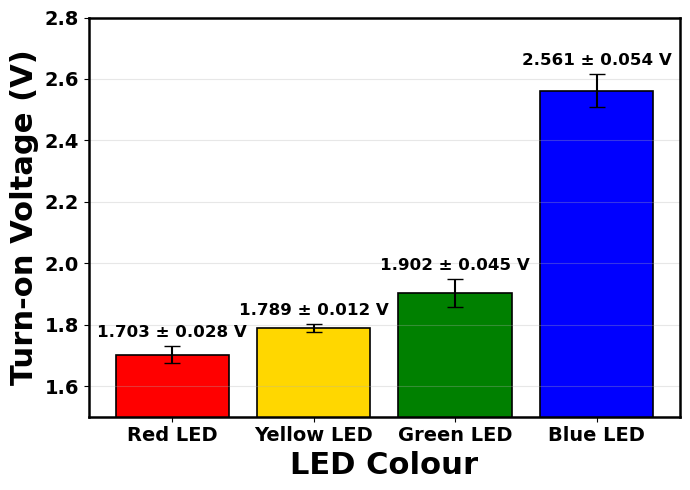

In [20]:
# ---- Turn-on voltage data (V) ----
Vt_green  = np.array([1.829, 1.964, 1.924, 1.882, 1.912])
Vt_blue   = np.array([2.462, 2.554, 2.573, 2.617, 2.600])
Vt_red    = np.array([1.662, 1.715, 1.742, 1.683, 1.711])
Vt_yellow = np.array([1.802, 1.801, 1.795, 1.775, 1.774])

def stats(arr):
    return np.mean(arr), np.std(arr)

labels = ["Red LED", "Yellow LED", "Green LED", "Blue LED"]
datasets = [Vt_red, Vt_yellow, Vt_green, Vt_blue]

means = []
errors = []

for arr in datasets:
    m, s = stats(arr)
    means.append(m)
    errors.append(s)

x = np.arange(len(labels))

# ---- Plot mean ± SD ----
plt.figure(figsize=(7,5))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

bars = plt.bar(
    x, means, yerr=errors, capsize=6,
    color=['red', 'gold', 'green', 'blue'],
    edgecolor='k', linewidth=1.2
)

plt.xticks(x, labels, fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.ylabel("Turn-on Voltage (V)", fontsize=22, fontweight='bold')
plt.xlabel("LED Colour", fontsize=22, fontweight='bold')

plt.ylim(1.5, 2.8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# ---- Annotate values ----
for bar, m, s in zip(bars, means, errors):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + s + 0.02,
        f"{m:.3f} ± {s:.3f} V",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

#plt.savefig("Turn-on Voltage Mean and SD.png", dpi=1200)
plt.show()

# 3. Extension - Liquid N2 cooled LED

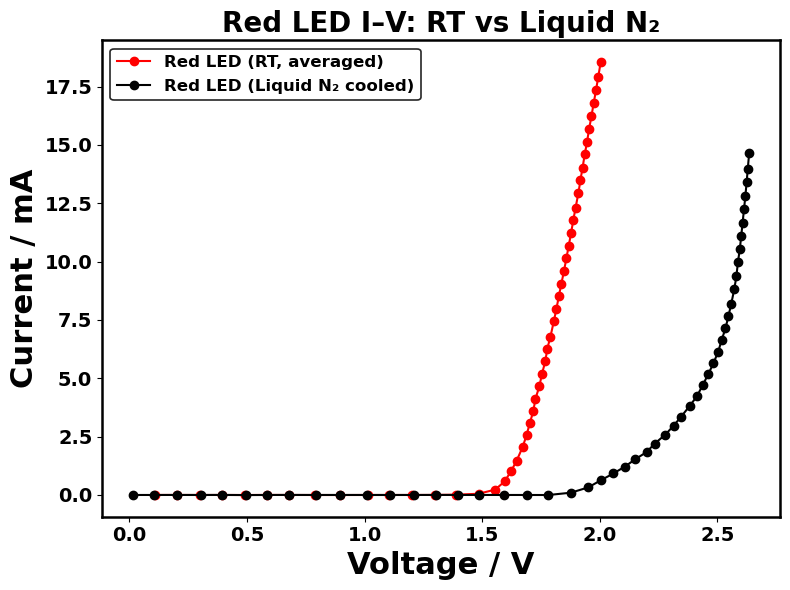

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/red'

V_red_rt, I_red_rt = average_iv([
    f'{base_rt}/red_IV.csv',
    f'{base_rt}/red_IV_2.csv',
    f'{base_rt}/red_IV_3.csv',
    f'{base_rt}/red_IV_4.csv',
    f'{base_rt}/red_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_red_ln2, I_red_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/red_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_red_rt, I_red_rt, 'o-', label='Red LED (RT, averaged)', color='red')
plt.plot(V_red_ln2, I_red_ln2, 'o-', label='Red LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Red LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
plt.savefig("Red_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

## 3.1 Red LED

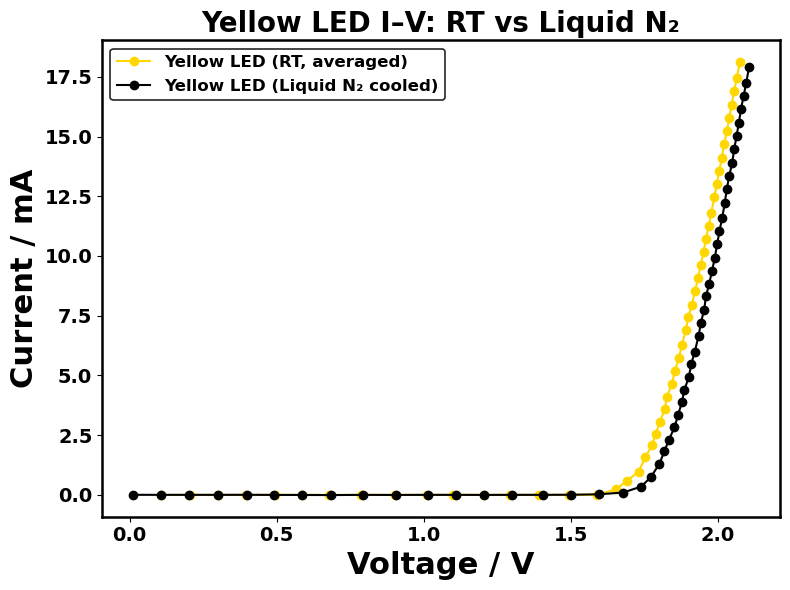

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data/yellow'

V_yellow_rt, I_yellow_rt = average_iv([
    f'{base_rt}/yellow_IV.csv',
    f'{base_rt}/yellow_IV_2.csv',
    f'{base_rt}/yellow_IV_3.csv',
    f'{base_rt}/yellow_IV_4.csv',
    f'{base_rt}/yellow_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_yellow_ln2, I_yellow_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/yellow_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_yellow_rt, I_yellow_rt, 'o-', label='Yellow LED (RT, averaged)', color='gold')
plt.plot(V_yellow_ln2, I_yellow_ln2, 'o-', label='Yellow LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Yellow LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
plt.savefig("Yellow_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

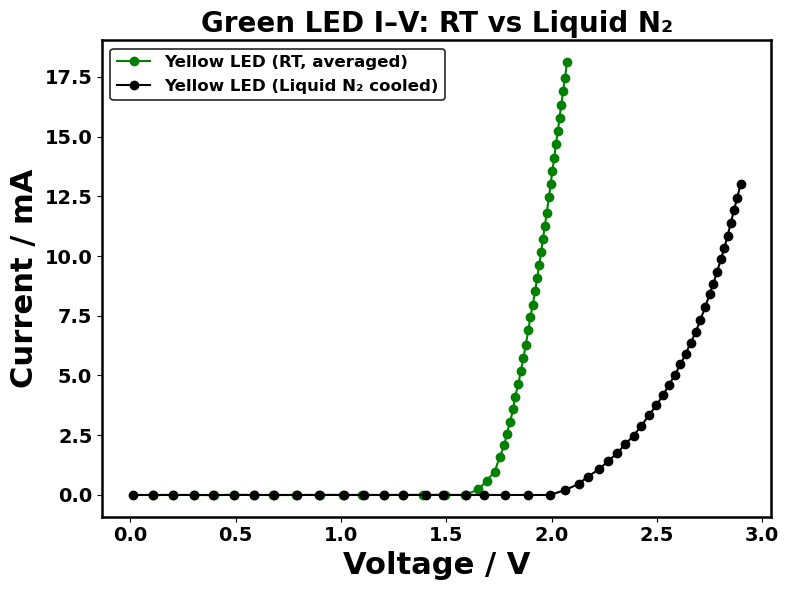

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/green'

V_green_rt, I_green_rt = average_iv([
    f'{base_rt}/green_IV.csv',
    f'{base_rt}/green_IV_2.csv',
    f'{base_rt}/green_IV_3.csv',
    f'{base_rt}/green_IV_4.csv',
    f'{base_rt}/green_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_yellow_ln2, I_yellow_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/green_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_yellow_rt, I_yellow_rt, 'o-', label='Yellow LED (RT, averaged)', color='green')
plt.plot(V_yellow_ln2, I_yellow_ln2, 'o-', label='Yellow LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Green LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
plt.savefig("Green_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

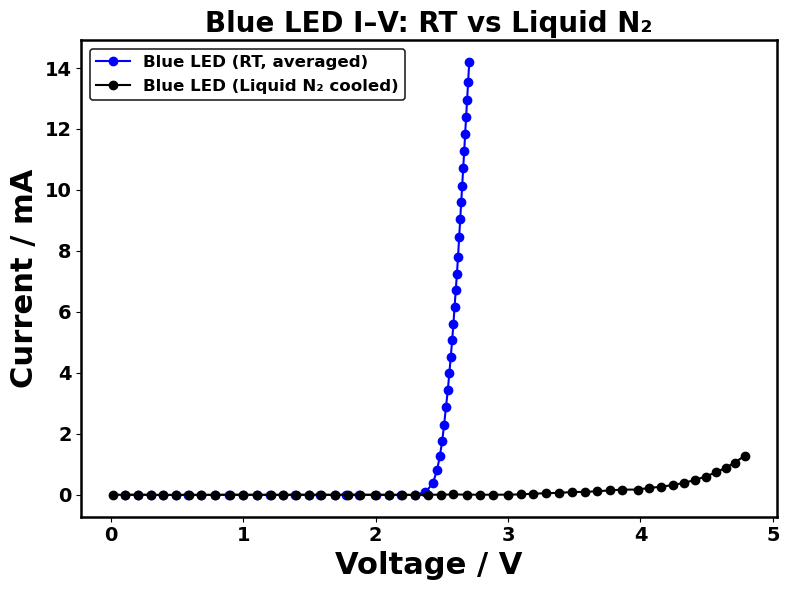

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/blue'

V_blue_rt, I_blue_rt = average_iv([
    f'{base_rt}/blue_IV.csv',
    f'{base_rt}/blue_IV_2.csv',
    f'{base_rt}/blue_IV_3.csv',
    f'{base_rt}/blue_IV_4.csv',
    f'{base_rt}/blue_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_blue_ln2, I_blue_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/blue_LiquidN2_cooled.csv'
)

# --------- Plot ----------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_rt, I_blue_rt, 'o-', label='Blue LED (RT, averaged)', color='blue')
plt.plot(V_blue_ln2, I_blue_ln2, 'o-', label='Blue LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Blue LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()
#plt.savefig("Blue_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

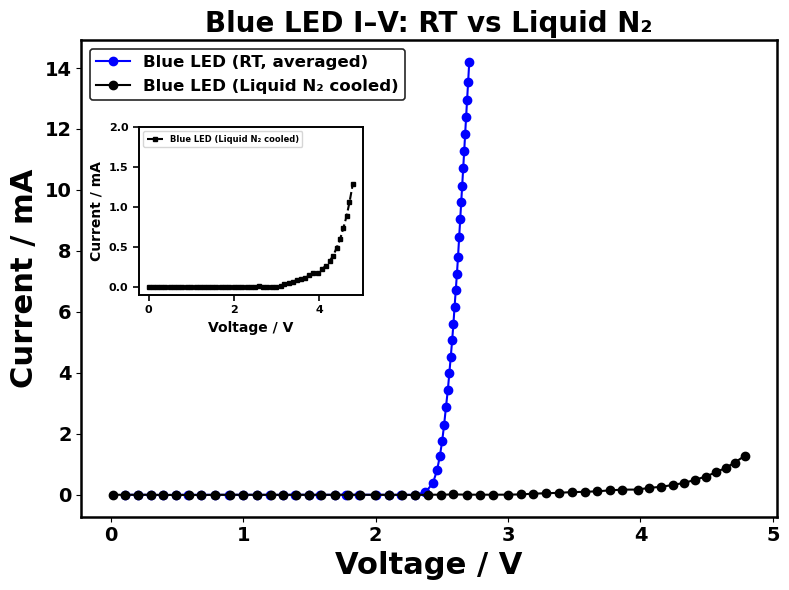

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/blue'

V_blue_rt, I_blue_rt = average_iv([
    f'{base_rt}/blue_IV.csv',
    f'{base_rt}/blue_IV_2.csv',
    f'{base_rt}/blue_IV_3.csv',
    f'{base_rt}/blue_IV_4.csv',
    f'{base_rt}/blue_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_blue_ln2, I_blue_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/blue_LiquidN2_cooled.csv'
)

# --------- Plot ----------
fig = plt.figure(figsize=(8, 6))     # <-- store figure in fig
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_rt, I_blue_rt, 'o-', label='Blue LED (RT, averaged)', color='blue')
plt.plot(V_blue_ln2, I_blue_ln2, 'o-', label='Blue LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Blue LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------- Inset plot ----------
inset_ax = fig.add_axes([0.18, 0.5, 0.28, 0.28])

inset_ax.plot(V_blue_ln2, I_blue_ln2, 's--', ms=3, color='black', label='Blue LED (Liquid N₂ cooled)')

inset_ax.set_xlabel("Voltage / V", fontsize=10, fontweight="bold")
inset_ax.set_ylabel("Current / mA", fontsize=10, fontweight="bold")

inset_ax.set_ylim(-0.1, 2)

inset_ax.tick_params(axis='both', width=1.2, length=4)
for tick in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_fontsize(8)

for spine in inset_ax.spines.values():
    spine.set_linewidth(1.4)

inset_ax.legend(loc='upper left', prop={'size': 6, 'weight': 'bold'})

plt.savefig("Blue_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

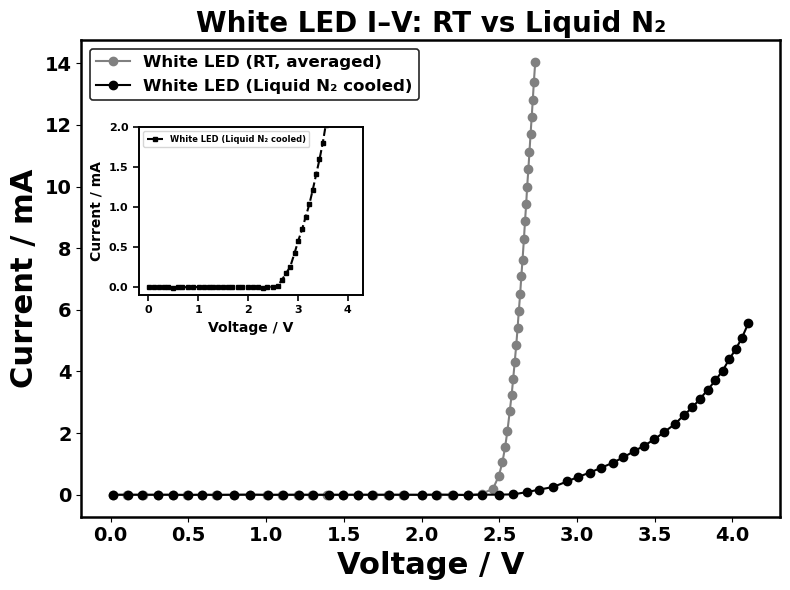

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs, Is = [], []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V); Is.append(I)

    n = min(len(v) for v in Vs)  # trim to shortest
    Vs_trim, Is_trim = [], []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V, I = V[drop:], I[drop:]
        else:
            V, I = V[:n], I[:n]
        Vs_trim.append(V); Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# --------- Room temperature (averaged) ----------
base_rt = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/white'

V_white_rt, I_white_rt = average_iv([
    f'{base_rt}/white_IV.csv',
    f'{base_rt}/white_IV_2.csv',
    f'{base_rt}/white_IV_3.csv',
    f'{base_rt}/white_IV_4.csv',
    f'{base_rt}/white_IV_5.csv',
])

# --------- Liquid N2 cooled (single run) ----------
V_white_ln2, I_white_ln2 = load_iv(
    '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/extension work/white_LiquidN2_cooled.csv'
)

# --------- Plot ----------
fig = plt.figure(figsize=(8, 6))     # <-- store figure in fig
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_white_rt, I_white_rt, 'o-', label='White LED (RT, averaged)', color='grey')
plt.plot(V_white_ln2, I_white_ln2, 'o-', label='White LED (Liquid N₂ cooled)', color='black')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('White LED I–V: RT vs Liquid N₂', fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

leg = plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left', frameon=True, fancybox=True)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(1.2)
frame.set_alpha(0.85)

plt.tight_layout()

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------- Inset plot ----------
inset_ax = fig.add_axes([0.18, 0.5, 0.28, 0.28])

inset_ax.plot(V_white_ln2, I_white_ln2, 's--', ms=3, color='black', label='White LED (Liquid N₂ cooled)')

inset_ax.set_xlabel("Voltage / V", fontsize=10, fontweight="bold")
inset_ax.set_ylabel("Current / mA", fontsize=10, fontweight="bold")

inset_ax.set_ylim(-0.1, 2)

inset_ax.tick_params(axis='both', width=1.2, length=4)
for tick in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_fontsize(8)

for spine in inset_ax.spines.values():
    spine.set_linewidth(1.4)

inset_ax.legend(loc='upper left', prop={'size': 6, 'weight': 'bold'})

plt.savefig("White_LED_IV_RT_vs_LN2.png", dpi=600)
plt.show()

# 4. Average Performance of I-V figures of 5 types of LEDs (with white) and the resistor

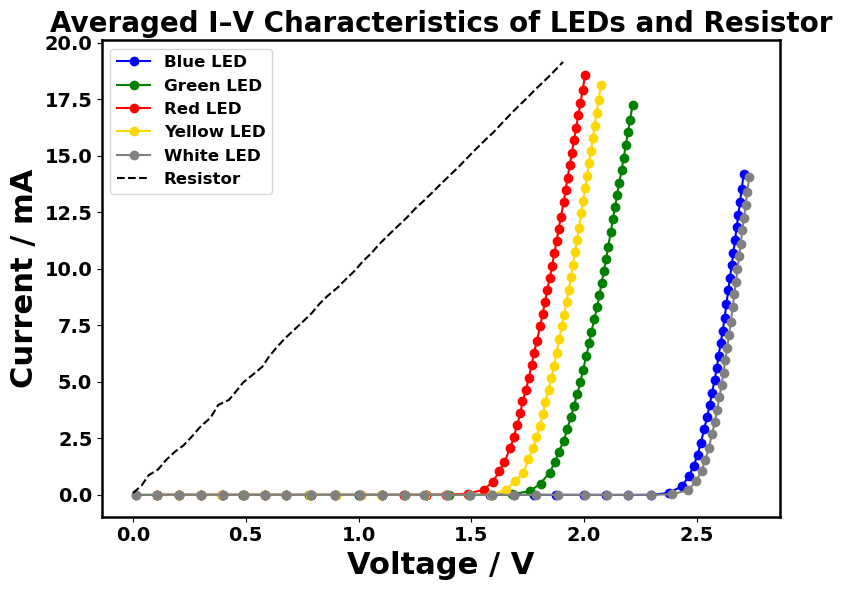

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def load_iv(filename):
    data = np.loadtxt(filename, delimiter=',', skiprows=1)
    return data[:, 0], data[:, 1]   # V, I

def average_iv(file_list):
    Vs = []
    Is = []
    for f in file_list:
        V, I = load_iv(f)
        Vs.append(V)
        Is.append(I)

    # target length = shortest run
    n = min(len(v) for v in Vs)

    Vs_trim = []
    Is_trim = []
    for V, I in zip(Vs, Is):
        if len(V) > n:
            drop = len(V) - n
            V = V[drop:]
            I = I[drop:]
        else:
            V = V[:n]
            I = I[:n]
        Vs_trim.append(V)
        Is_trim.append(I)

    V_avg = np.mean(np.vstack(Vs_trim), axis=0)
    I_avg = np.mean(np.vstack(Is_trim), axis=0)
    return V_avg, I_avg

# ----------------- Existing base (ICCE 20260119) -----------------
base = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260119/raw data'

V_blue_avg, I_blue_avg = average_iv([
    f'{base}/blue/blue_IV.csv',
    f'{base}/blue/blue_IV_2.csv',
    f'{base}/blue/blue_IV_3.csv',
    f'{base}/blue/blue_IV_4.csv',
    f'{base}/blue/blue_IV_5.csv',
])

V_green_avg, I_green_avg = average_iv([
    f'{base}/green/green_IV.csv',
    f'{base}/green/green_IV_2.csv',
    f'{base}/green/green_IV_3.csv',
    f'{base}/green/green_IV_4.csv',
    f'{base}/green/green_IV_5.csv',
])

V_red_avg, I_red_avg = average_iv([
    f'{base}/red/red_IV.csv',
    f'{base}/red/red_IV_2.csv',
    f'{base}/red/red_IV_3.csv',
    f'{base}/red/red_IV_4.csv',
    f'{base}/red/red_IV_5.csv',
])

V_yellow_avg, I_yellow_avg = average_iv([
    f'{base}/yellow/yellow_IV.csv',
    f'{base}/yellow/yellow_IV_2.csv',
    f'{base}/yellow/yellow_IV_3.csv',
    f'{base}/yellow/yellow_IV_4.csv',
    f'{base}/yellow/yellow_IV_5.csv',
])

V_res_avg, I_res_avg = average_iv([
    f'{base}/resistor/resistor_IV.csv',
    f'{base}/resistor/resistor_IV_2.csv',
    f'{base}/resistor/resistor_IV_3.csv',
    f'{base}/resistor/resistor_IV_4.csv',
    f'{base}/resistor/resistor_IV_5.csv',
])

# ----------------- NEW: White LED averaged (ICCE 20260120) -----------------
base_white = '/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260120/raw data/white'

V_white_avg, I_white_avg = average_iv([
    f'{base_white}/white_IV.csv',
    f'{base_white}/white_IV_2.csv',
    f'{base_white}/white_IV_3.csv',
    f'{base_white}/white_IV_4.csv',
    f'{base_white}/white_IV_5.csv',
])

# ----------------- Plot -----------------
plt.figure(figsize=(8, 6))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(V_blue_avg, I_blue_avg, 'o-', label='Blue LED', color='blue')
plt.plot(V_green_avg, I_green_avg, 'o-', label='Green LED', color='green')
plt.plot(V_red_avg, I_red_avg, 'o-', label='Red LED', color='red')
plt.plot(V_yellow_avg, I_yellow_avg, 'o-', label='Yellow LED', color='gold')
plt.plot(V_white_avg, I_white_avg, 'o-', label='White LED', color='grey')  # <-- added
plt.plot(V_res_avg, I_res_avg, 'k--', label='Resistor')

plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
plt.title('Averaged I–V Characteristics of LEDs and Resistor', fontsize=20, fontweight="bold")
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper left')
plt.tight_layout()
plt.savefig("Averaged I–V Characteristics of LEDs and Resistor (with White).png", dpi=600)
plt.show()

## Error bar for white LED also needed.